# Workflow Baseline Full Run – Both Routes
Plots built from `output/workflow_baseline_full_run_both_routes/{bm25,dense,hybrid}`.

https://github.com/fulaibaowang/BioASQ/issues/4

## 1. Imports and Setup

In [19]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (14, 10)
plt.rcParams["axes.grid"] = False
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12

## 2. Load Data

In [20]:
base_dir = Path.cwd().resolve()
if not (base_dir / "output").exists() and (base_dir.parent / "output").exists():
    base_dir = base_dir.parent

print("Base dir:", base_dir)

workflow_dir = base_dir / "output" / "workflow_baseline_full_run_both_routes"

bm25_metrics = pd.read_csv(workflow_dir / "bm25" / "metrics.csv")
dense_metrics = pd.read_csv(workflow_dir / "dense" / "metrics.csv")
hybrid_metrics = pd.read_csv(workflow_dir / "hybrid" / "metrics.csv")

# Normalise split column name
bm25_metrics = bm25_metrics.rename(columns={"batch": "split"})
dense_metrics = dense_metrics.rename(columns={"batch": "split"})

bm25_metrics["method"] = "BM25"
dense_metrics["method"] = "Dense"
hybrid_metrics["method"] = "BM25 Dense Fusion"

output_dir = workflow_dir / "figures"
output_dir.mkdir(parents=True, exist_ok=True)

print("Loaded BM25:", bm25_metrics.shape)
print("Loaded Dense:", dense_metrics.shape)
print("Loaded Hybrid:", hybrid_metrics.shape)

Base dir: /Users/yun/develop/BioASQ
Loaded BM25: (5, 17)
Loaded Dense: (5, 17)
Loaded Hybrid: (5, 28)


## 3. Stage 1 Recall Curves – Per Split (3×2 panels)

Shared K values: [10, 50, 100, 200, 300, 400, 500, 1000, 2000, 5000]
Saved: /Users/yun/develop/BioASQ/output/workflow_baseline_full_run_both_routes/figures/01_stage1_recall_per_split.png


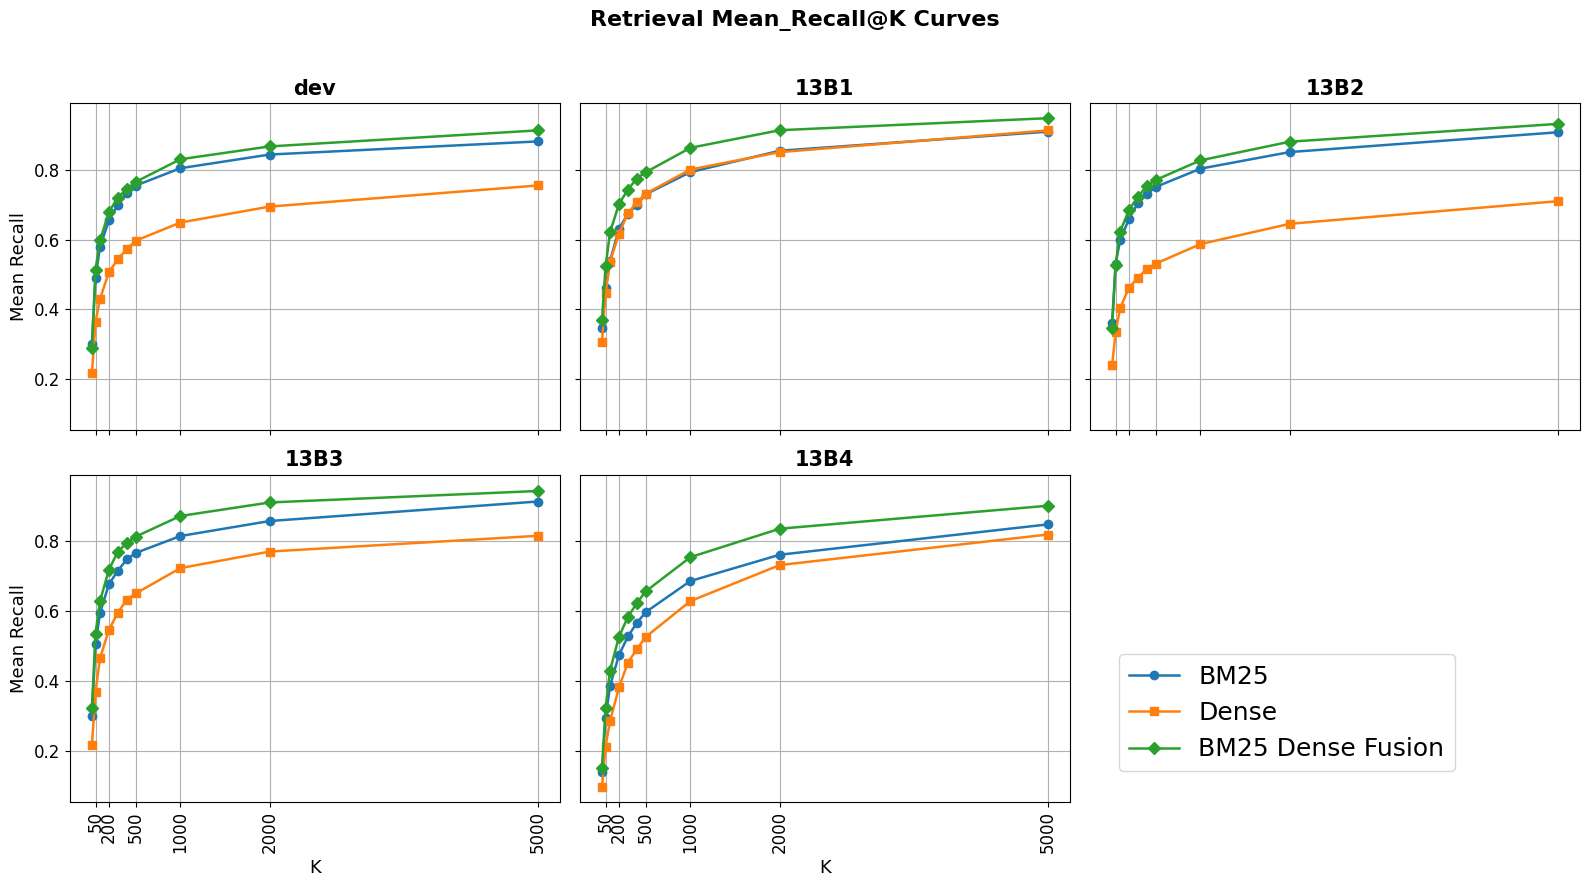

In [21]:
splits = [
    "training14b_10pct_sample",
    "13B1_golden",
    "13B2_golden",
    "13B3_golden",
    "13B4_golden",
]
split_labels = {
    "training14b_10pct_sample": "dev",
    "13B1_golden": "13B1",
    "13B2_golden": "13B2",
    "13B3_golden": "13B3",
    "13B4_golden": "13B4",
}

recall_cols_bm25 = sorted(
    [c for c in bm25_metrics.columns if c.startswith("MeanR@")],
    key=lambda c: int(c.split("@")[1]),
)
recall_cols_hybrid = sorted(
    [c for c in hybrid_metrics.columns if c.startswith("MeanR@")],
    key=lambda c: int(c.split("@")[1]),
)
recall_cols = sorted(
    set(recall_cols_bm25) & set(recall_cols_hybrid),
    key=lambda c: int(c.split("@")[1]),
)
k_values = [int(c.split("@")[1]) for c in recall_cols]

print("Shared K values:", k_values)

# Only show a subset of K ticks to avoid clutter.
tick_candidates = [50, 200, 500, 1000, 2000, 5000]
tick_values = [k for k in tick_candidates if k in k_values]

methods_cfg = {
    "BM25": {"df": bm25_metrics, "color": "#1f77b4", "marker": "o"},
    "Dense": {"df": dense_metrics, "color": "#ff7f0e", "marker": "s"},
    "BM25 Dense Fusion": {"df": hybrid_metrics, "color": "#2ca02c", "marker": "D"},
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True, sharey=True)
axes_flat = axes.flat

global_ymin, global_ymax = 1.0, 0.0
for split in splits:
    for cfg in methods_cfg.values():
        row = cfg["df"][cfg["df"]["split"] == split]
        if row.empty:
            continue
        vals = [row.iloc[0][c] for c in recall_cols]
        global_ymin = min(global_ymin, min(vals))
        global_ymax = max(global_ymax, max(vals))

y_pad = (global_ymax - global_ymin) * 0.05
global_ymin = max(0, global_ymin - y_pad)
global_ymax = min(1, global_ymax + y_pad)

for idx, split in enumerate(splits):
    ax = axes_flat[idx]
    for method_name, cfg in methods_cfg.items():
        row = cfg["df"][cfg["df"]["split"] == split]
        if row.empty:
            continue
        vals = [row.iloc[0][c] for c in recall_cols]
        ax.plot(
            k_values,
            vals,
            marker=cfg["marker"],
            color=cfg["color"],
            label=method_name,
            markersize=6,
            linewidth=1.8,
        )

    ax.set_title(split_labels.get(split, split), fontsize=15, fontweight="bold")
    ax.set_ylim(global_ymin, global_ymax)

    # Y-axis label only for left column (two left plots)
    if idx % 3 == 0:
        ax.set_ylabel("Mean Recall")
    else:
        ax.set_ylabel("")

    # X-axis label (and tick labels) only for bottom row (two bottom plots actually used)
    if idx >= 3:
        ax.set_xlabel("K")
        ax.set_xticks(tick_values)
        ax.set_xticklabels([str(k) for k in tick_values], rotation=90)
    else:
        ax.set_xlabel("")
        ax.set_xticklabels([])

    # Grid: horizontal lines on all panels, vertical lines at selected K ticks
    ax.grid(True, axis="y")
    ax.grid(True, axis="x")

last_ax = axes_flat[len(splits)]
last_ax.axis("off")

handles, labels = axes_flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower right", bbox_to_anchor=(0.92, 0.12), fontsize=18)

fig.suptitle("Retrieval Mean_Recall@K Curves", fontsize=16, fontweight="bold", y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
fig_path = output_dir / "01_stage1_recall_per_split.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()

## 4. Hybrid vs Rerank vs Post-rerank Fusion – Recall Curves (K ≤ 300)

Stage2+ K values (≤300): [10, 50, 100, 200, 300]
Saved: /Users/yun/develop/BioASQ/output/workflow_baseline_full_run_both_routes/figures/02_hybrid_rerank_fusion_recall_per_split.png


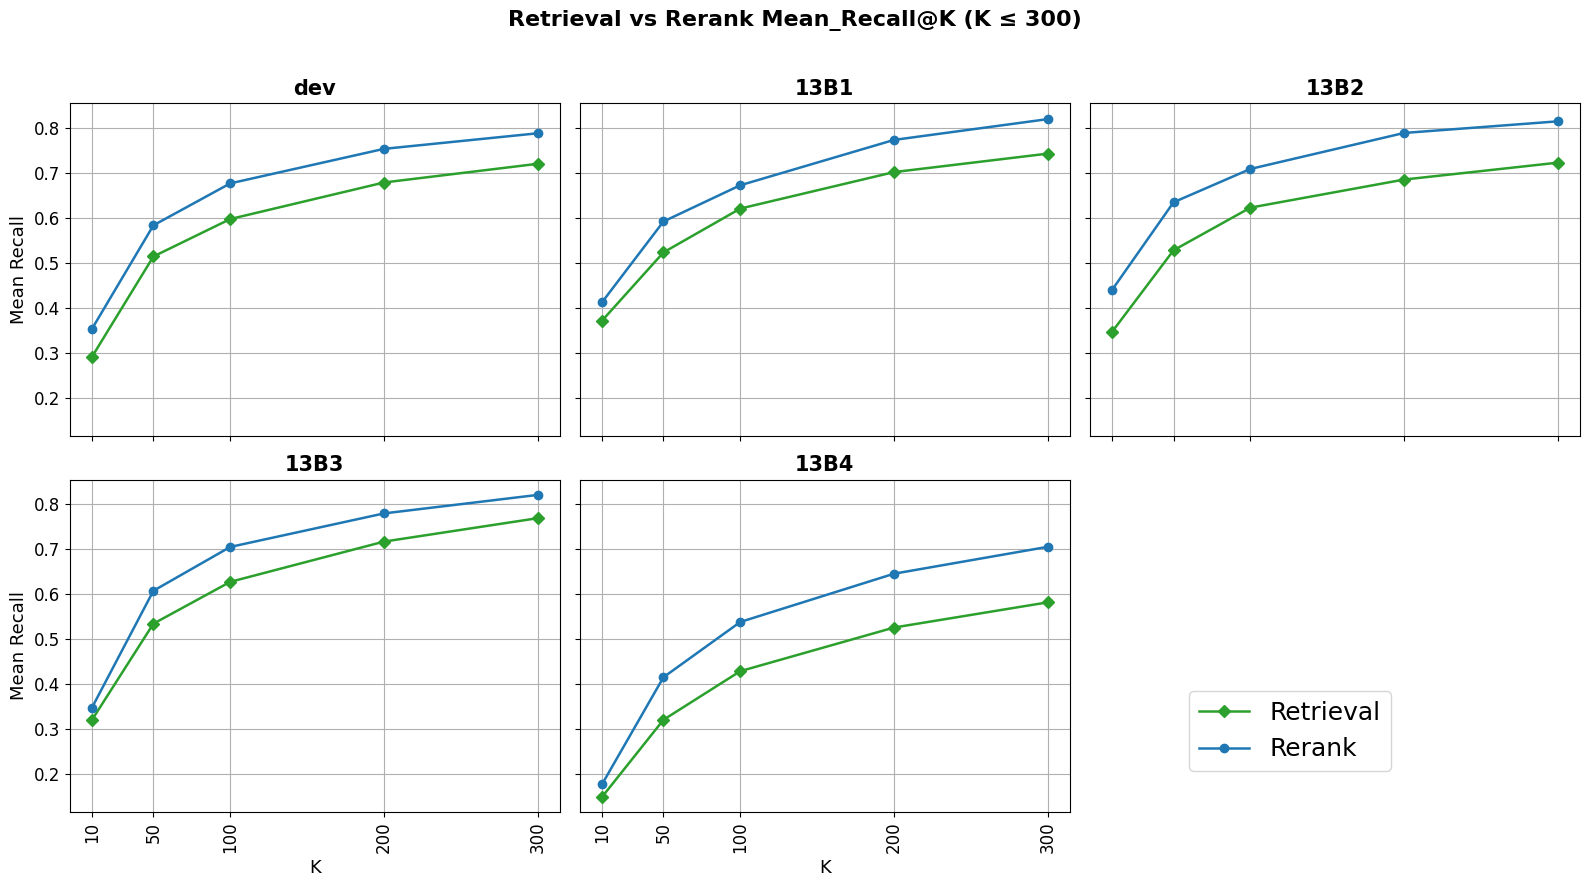

In [22]:
hybrid_stage1 = hybrid_metrics.copy()
rerank_metrics = pd.read_csv(workflow_dir / "rerank" / "metrics.csv")
rerank_fusion_metrics = pd.read_csv(workflow_dir / "rerank_hybrid_200" / "metrics.csv")

# Rerank uses 'label' for split name
rerank_metrics = rerank_metrics.rename(columns={"label": "split"})

methods_stage2 = {
    "Retrieval": {
        "df": hybrid_stage1,
        "color": "#2ca02c",
        "marker": "D",
    },
    "Rerank": {
        "df": rerank_metrics,
        "color": "#1f77b4",
        "marker": "o",
    },
}

# Shared MeanR@K columns with K in [10, 300]
recall_cols_all = []
for df in [hybrid_stage1, rerank_metrics]:
    cols = [c for c in df.columns if c.startswith("MeanR@")]
    recall_cols_all.append(set(cols))

recall_cols_common = sorted(
    set.intersection(*recall_cols_all),
    key=lambda c: int(c.split("@")[1]),
)
k_vals_recall = [int(c.split("@")[1]) for c in recall_cols_common if 10 <= int(c.split("@")[1]) <= 300]
recall_cols_common = [f"MeanR@{k}" for k in k_vals_recall]

print("Stage2+ K values (≤300):", k_vals_recall)

fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True, sharey=True)
axes_flat = axes.flat

global_ymin, global_ymax = 1.0, 0.0
for split in splits:
    for cfg in methods_stage2.values():
        row = cfg["df"][cfg["df"]["split"] == split]
        if row.empty:
            continue
        vals = [row.iloc[0][c] for c in recall_cols_common]
        global_ymin = min(global_ymin, min(vals))
        global_ymax = max(global_ymax, max(vals))

y_pad = (global_ymax - global_ymin) * 0.05
global_ymin = max(0, global_ymin - y_pad)
global_ymax = min(1, global_ymax + y_pad)

tick_candidates_recall = [10, 50, 100, 200, 300,]
tick_values_recall = [k for k in tick_candidates_recall if k in k_vals_recall]

for idx, split in enumerate(splits):
    ax = axes_flat[idx]
    for method_name, cfg in methods_stage2.items():
        row = cfg["df"][cfg["df"]["split"] == split]
        if row.empty:
            continue
        vals = [row.iloc[0][c] for c in recall_cols_common]
        ax.plot(
            k_vals_recall,
            vals,
            marker=cfg["marker"],
            color=cfg["color"],
            label=method_name,
            markersize=6,
            linewidth=1.8,
        )

    ax.set_title(split_labels.get(split, split), fontsize=15, fontweight="bold")
    ax.set_ylim(global_ymin, global_ymax)

    if idx % 3 == 0:
        ax.set_ylabel("Mean Recall")
    else:
        ax.set_ylabel("")

    if idx >= 3:
        ax.set_xlabel("K")
        ax.set_xticks(tick_values_recall)
        ax.set_xticklabels([str(k) for k in tick_values_recall], rotation=90)
    else:
        ax.set_xlabel("")
        ax.set_xticklabels([])

    ax.grid(True, axis="y")
    ax.grid(True, axis="x")

last_ax = axes_flat[len(splits)]
last_ax.axis("off")

handles, labels = axes_flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower right", bbox_to_anchor=(0.88, 0.12), fontsize=18)

fig.suptitle("Retrieval vs Rerank Mean_Recall@K (K ≤ 300)", fontsize=16, fontweight="bold", y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
fig_path = output_dir / "02_hybrid_rerank_fusion_recall_per_split.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()

## 5. Hybrid vs Rerank vs Post-rerank Fusion – MAP@10 (Bar Plots)

Saved: /Users/yun/develop/BioASQ/output/workflow_baseline_full_run_both_routes/figures/03_hybrid_rerank_fusion_map10_bars_per_split.png


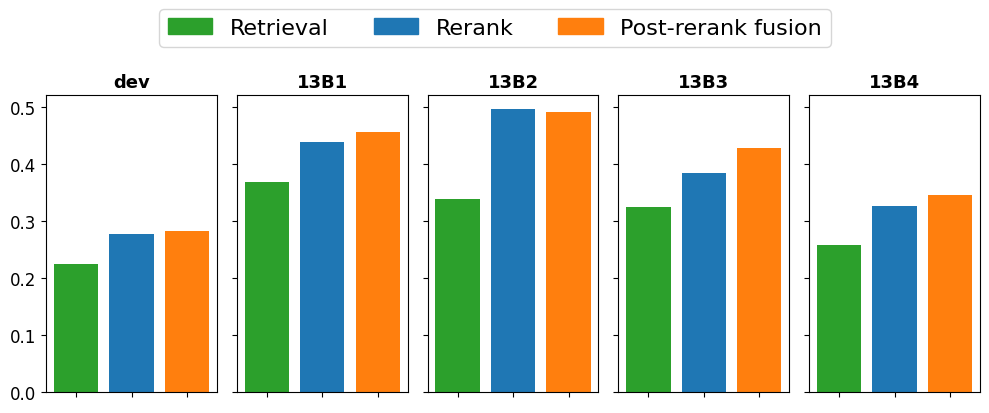

In [23]:
fig, ax = plt.subplots(1, 5, figsize=(10, 4), sharey=True)
# fig.suptitle("Retrival vs Rerank vs Post-rerank Fusion – MAP@10", fontsize=16, fontweight="bold", y=1.08)
method_colors = {
    "Retrieval": "#2ca02c",
    "Rerank": "#1f77b4",
    "Post-rerank fusion": "#ff7f0e",
}

for idx, split in enumerate(splits):
    cur_ax = ax[idx]
    vals = []
    labels_methods = []

    # Hybrid retrieval
    row_h = hybrid_stage1[hybrid_stage1["split"] == split]
    if not row_h.empty:
        vals.append(float(row_h.iloc[0]["MAP@10"]))
        labels_methods.append("Retrieval")

    # Rerank
    row_r = rerank_metrics[rerank_metrics["split"] == split]
    if not row_r.empty:
        vals.append(float(row_r.iloc[0]["MAP@10"]))
        labels_methods.append("Rerank")

    # Post-rerank fusion
    row_f = rerank_fusion_metrics[rerank_fusion_metrics["split"] == split]
    if not row_f.empty:
        vals.append(float(row_f.iloc[0]["MAP@10"]))
        labels_methods.append("Post-rerank fusion")

    x = np.arange(len(labels_methods))
    colors = [method_colors[label] for label in labels_methods]
    cur_ax.bar(x, vals, color=colors)
    cur_ax.set_xticks(x)
    cur_ax.set_xticklabels("", rotation=30, ha="right")
    cur_ax.set_title(split_labels.get(split, split), fontsize=13, fontweight="bold")

# Legend for methods instead of y-axis label
handles = [
    plt.matplotlib.patches.Patch(color=method_colors["Retrieval"], label="Retrieval"),
    plt.matplotlib.patches.Patch(color=method_colors["Rerank"], label="Rerank"),
    plt.matplotlib.patches.Patch(color=method_colors["Post-rerank fusion"], label="Post-rerank fusion"),
]
fig.legend(handles=handles, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.05), fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.9])
fig_path = output_dir / "03_hybrid_rerank_fusion_map10_bars_per_split.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()

## 6. Hybrid vs Rerank vs Post-rerank Fusion – MAP@K Curves (K = 1, 3, 5, 10, 20, 30, 40, 50)

Saved: /Users/yun/develop/BioASQ/output/workflow_baseline_full_run_both_routes/figures/04_hybrid_rerank_fusion_mapk_per_split.png


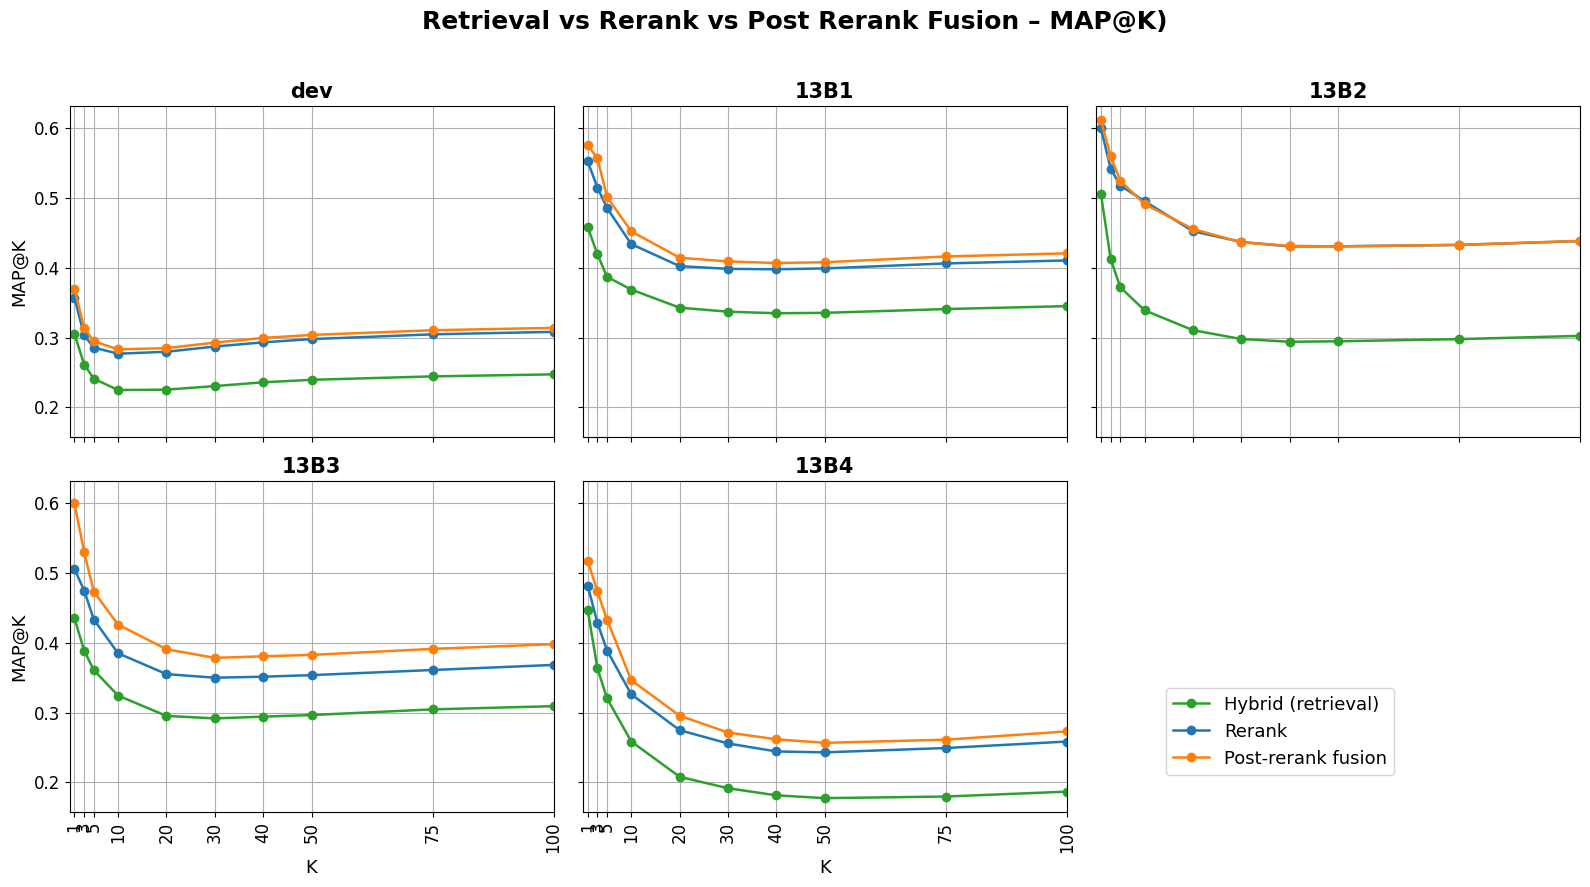

In [24]:
from collections import defaultdict

map_ks = [1, 3, 5, 10, 20, 30, 40, 50, 75, 100]


def _extract_pmid(doc_entry):
    if isinstance(doc_entry, dict):
        doc_entry = doc_entry.get("document", "")
    if not isinstance(doc_entry, str):
        return None
    if "/" in doc_entry:
        return doc_entry.rsplit("/", 1)[-1]
    return doc_entry


def _load_qrels(path: Path) -> dict[str, set[str]]:
    with path.open("r", encoding="utf-8") as f:
        data = json.load(f)
    qrels: dict[str, set[str]] = {}
    for q in data.get("questions", []):
        qid = str(q.get("id"))
        docs = q.get("documents", [])
        pmids = {
            _extract_pmid(d)
            for d in docs
            if _extract_pmid(d)
        }
        if qid and pmids:
            qrels[qid] = pmids
    return qrels


def _load_run(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, sep="\t")
    cols = {c.lower(): c for c in df.columns}
    qid_col = cols.get("qid")
    doc_col = cols.get("docno") or cols.get("docid") or cols.get("doc")
    rank_col = cols.get("rank")
    if qid_col is None or doc_col is None:
        raise ValueError(f"Missing qid/doc columns in {path}")
    df[qid_col] = df[qid_col].astype(str)
    df[doc_col] = df[doc_col].astype(str)
    if rank_col:
        df = df.sort_values([qid_col, rank_col])
    return df[[qid_col, doc_col]]


def _ap_at_k(docs: list[str], rels: set[str], k: int) -> float:
    """BioASQ-style AP@k, matching retrieval_eval.common.ap_at_k."""
    if not rels:
        return 0.0
    denom = min(len(rels), k)
    if denom == 0:
        return 0.0
    hits = 0
    score = 0.0
    for i, doc in enumerate(docs[:k], start=1):
        if doc in rels:
            hits += 1
            score += hits / i
    return score / denom


def _map_at_ks_for_run(run_df: pd.DataFrame, qrels: dict[str, set[str]], ks: list[int]) -> dict[int, float]:
    qid_col, doc_col = run_df.columns.tolist()
    per_q: dict[int, list[float]] = {k: [] for k in ks}
    for qid, group in run_df.groupby(qid_col, sort=False):
        rels = qrels.get(str(qid))
        if not rels:
            continue
        docs = group[doc_col].tolist()
        for k in ks:
            per_q[k].append(_ap_at_k(docs, rels, k))
    return {k: (float(np.mean(v)) if v else 0.0) for k, v in per_q.items()}


qrels_paths = {
    "training14b_10pct_sample": base_dir / "example" / "training14b_10pct_sample.json",
    "13B1_golden": base_dir / "bioasq_data" / "Task13BGoldenEnriched" / "13B1_golden.json",
    "13B2_golden": base_dir / "bioasq_data" / "Task13BGoldenEnriched" / "13B2_golden.json",
    "13B3_golden": base_dir / "bioasq_data" / "Task13BGoldenEnriched" / "13B3_golden.json",
    "13B4_golden": base_dir / "bioasq_data" / "Task13BGoldenEnriched" / "13B4_golden.json",
}

qrels_by_split = {s: _load_qrels(p) for s, p in qrels_paths.items()}

run_dirs = {
    "Hybrid (retrieval)": workflow_dir / "hybrid" / "runs",
    "Rerank": workflow_dir / "rerank" / "runs",
    "Post-rerank fusion": workflow_dir / "rerank_hybrid_200" / "runs",
}

map_curves: dict[str, dict[str, dict[int, float]]] = defaultdict(dict)

for split in splits:
    qrels_split = qrels_by_split.get(split, {})
    for method_name, runs_dir in run_dirs.items():
        # Hybrid and rerank use simple pattern; fusion has extra suffix but same prefix.
        pattern = f"best_rrf_{split}_top5000"
        candidates = list(runs_dir.glob(f"{pattern}*.tsv"))
        if not candidates:
            continue
        run_path = candidates[0]
        run_df = _load_run(run_path)
        map_vals = _map_at_ks_for_run(run_df, qrels_split, map_ks)
        map_curves[method_name][split] = map_vals

fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True, sharey=True)
axes_flat = axes.flat

all_maps = []
for method_dict in map_curves.values():
    for split_vals in method_dict.values():
        all_maps.extend(split_vals.values())

if all_maps:
    y_min = max(0.0, min(all_maps) - 0.02)
    y_max = min(1.0, max(all_maps) + 0.02)
else:
    y_min, y_max = 0.0, 1.0

colors_map = {
    "Hybrid (retrieval)": "#2ca02c",
    "Rerank": "#1f77b4",
    "Post-rerank fusion": "#ff7f0e",
}

for idx, split in enumerate(splits):
    ax = axes_flat[idx]
    for method_name, method_dict in map_curves.items():
        if split not in method_dict:
            continue
        vals = [method_dict[split].get(k, 0.0) for k in map_ks]
        ax.plot(
            map_ks,
            vals,
            marker="o",
            color=colors_map.get(method_name),
            label=method_name,
            linewidth=1.8,
        )
    ax.set_title(split_labels.get(split, split), fontsize=15, fontweight="bold")
    ax.set_ylim(y_min, y_max)

    if idx % 3 == 0:
        ax.set_ylabel("MAP@K")
    else:
        ax.set_ylabel("")

    if idx >= 3:
        ax.set_xlabel("K")
        ax.set_xticks(map_ks)
        ax.set_xticklabels([str(k) for k in map_ks], rotation=90)
    else:
        ax.set_xlabel("")
        ax.set_xticklabels([])

    ax.set_xlim(0, 100)
    ax.grid(True, axis="y")
    ax.grid(True, axis="x")

last_ax = axes_flat[len(splits)]
last_ax.axis("off")

handles, labels = axes_flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower right", bbox_to_anchor=(0.88, 0.12), fontsize=13)

fig.suptitle("Retrieval vs Rerank vs Post Rerank Fusion – MAP@K)", fontsize=18, fontweight="bold", y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
fig_path = output_dir / "04_hybrid_rerank_fusion_mapk_per_split.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()

## 7. Gold Count Histogram per Query (Dev + Test Combined)

Saved: /Users/yun/develop/BioASQ/output/workflow_baseline_full_run_both_routes/figures/05_gold_count_hist_all.png


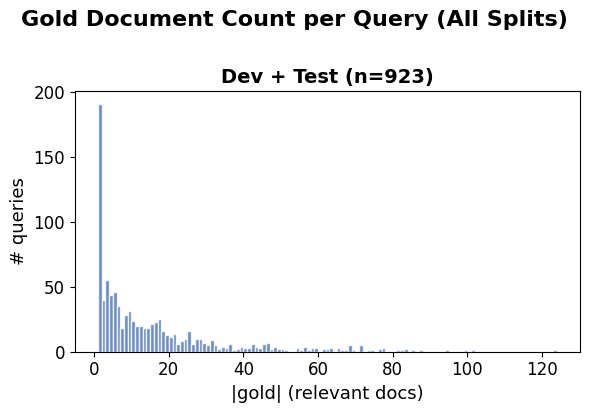

In [25]:
dev_split = "training14b_10pct_sample"
test_splits = ["13B1_golden", "13B2_golden", "13B3_golden", "13B4_golden"]

gold_counts_all = [len(v) for v in qrels_by_split[dev_split].values()]
for s in test_splits:
    gold_counts_all.extend(len(v) for v in qrels_by_split[s].values())

max_gold = max(gold_counts_all) if gold_counts_all else 0
bins = range(1, max_gold + 2) if max_gold > 0 else [0, 1]

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(gold_counts_all, bins=bins, color="#4c72b0", alpha=0.8, edgecolor="white")
ax.set_xlabel("|gold| (relevant docs)")
ax.set_ylabel("# queries")
ax.set_title(f"Dev + Test (n={len(gold_counts_all)})", fontweight="bold")

fig.suptitle("Gold Document Count per Query (All Splits)", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
fig_path = output_dir / "05_gold_count_hist_all.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()

## 8. MAP@K Stratified by Gold Count (All Splits; |gold| = 1, 2, 3–5, >5)

Per-query AP@K rows: 27690
Saved: /Users/yun/develop/BioASQ/output/workflow_baseline_full_run_both_routes/figures/06_mapk_by_gold_bucket_all.png


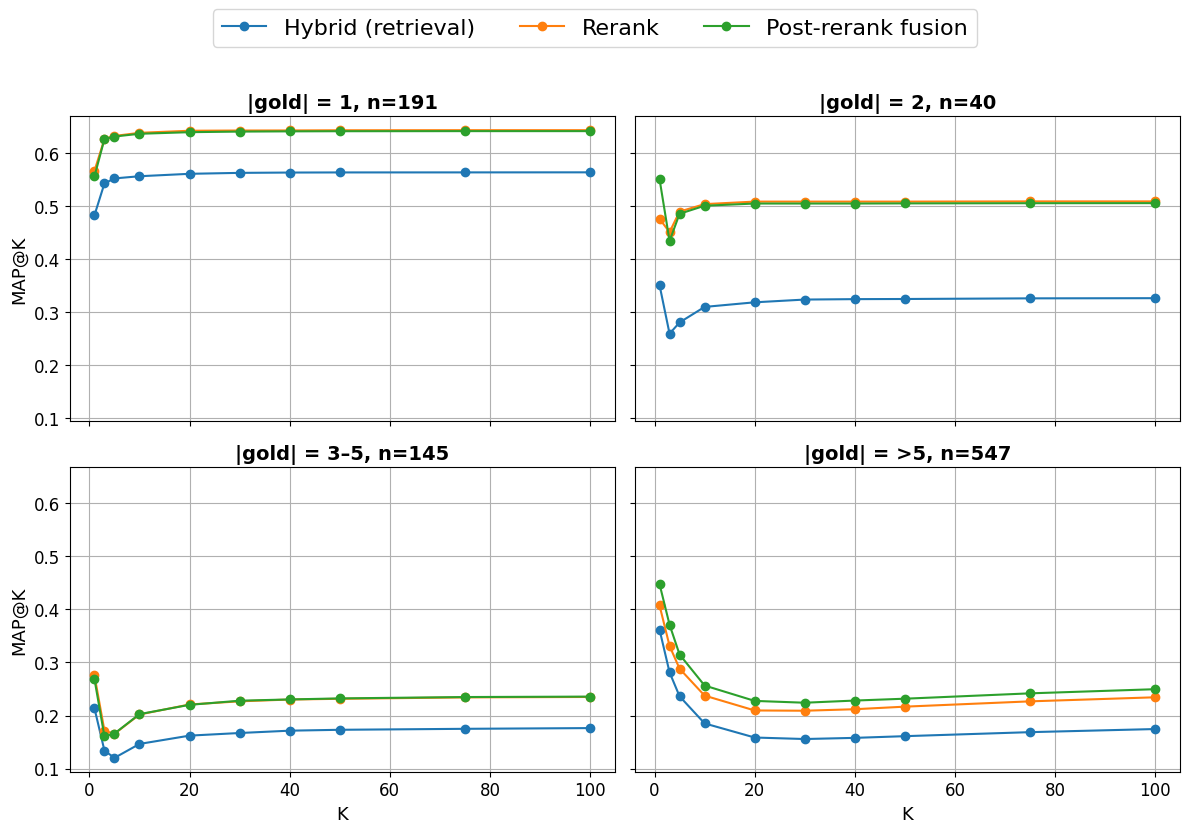

In [26]:
bucket_order = ["1", "2", "3–5", ">5"]


def _gold_bucket(n: int) -> str:
    if n == 1:
        return "1"
    if n == 2:
        return "2"
    if 3 <= n <= 5:
        return "3–5"
    return ">5"


records = []
for method_name, runs_dir in run_dirs.items():
    for split in [dev_split] + test_splits:
        qrels_split = qrels_by_split[split]
        pattern = f"best_rrf_{split}_top5000"
        candidates = list(runs_dir.glob(f"{pattern}*.tsv"))
        if not candidates:
            continue
        run_path = candidates[0]
        run_df = _load_run(run_path)

        qid_col, doc_col = run_df.columns.tolist()
        for qid, group in run_df.groupby(qid_col, sort=False):
            rels = qrels_split.get(str(qid))
            if not rels:
                continue
            gold_n = len(rels)
            bucket = _gold_bucket(gold_n)
            docs = group[doc_col].tolist()
            for k in map_ks:
                ap = _ap_at_k(docs, set(rels), k)
                records.append(
                    {
                        "split": split,
                        "method": method_name,
                        "qid": str(qid),
                        "gold_n": gold_n,
                        "bucket": bucket,
                        "k": k,
                        "AP@K": ap,
                    }
                )

map_pq_df = pd.DataFrame(records)
print("Per-query AP@K rows:", len(map_pq_df))

# Compute MAP@K aggregated over all splits
summary = (
    map_pq_df.groupby(["method", "bucket", "k"], as_index=False)["AP@K"]
    .mean()
    .rename(columns={"AP@K": "MAP@K"})
)

# Compute per-bucket sample sizes (unique queries)
bucket_counts = (
    map_pq_df[["qid", "bucket"]]
    .drop_duplicates()
    .groupby("bucket")["qid"]
    .nunique()
    .to_dict()
)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes_flat = axes.flat

for idx, bucket in enumerate(bucket_order):
    ax = axes_flat[idx]
    bucket_df = summary[summary["bucket"] == bucket]
    if bucket_df.empty:
        ax.set_visible(False)
        continue
    for method_name in run_dirs.keys():
        m_df = bucket_df[bucket_df["method"] == method_name]
        if m_df.empty:
            continue
        ax.plot(
            m_df["k"],
            m_df["MAP@K"],
            marker="o",
            label=method_name,
        )
    n_bucket = bucket_counts.get(bucket, 0)
    ax.set_title(f"|gold| = {bucket}, n={n_bucket}", fontweight="bold")
    ax.grid(True, axis="y")
    ax.grid(True, axis="x")
    if idx % 2 == 0:
        ax.set_ylabel("MAP@K")
    if idx >= 2:
        ax.set_xlabel("K")

handles, labels = axes_flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(run_dirs), bbox_to_anchor=(0.5, 1.05), fontsize=16)

#fig.suptitle("MAP@K by Gold Count – Dev + Test Combined", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.95])
fig_path = output_dir / "06_mapk_by_gold_bucket_all.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()

## 9. MAP@K Curves – Rerankers Across Configs (Train + Test Splits)
Note: for the train/dev split we drop any queries whose IDs also appear in the
test batches (13B1–4) to avoid training/eval overlap.

Saved: /Users/yun/develop/BioASQ/output/workflow_baseline_full_run_both_routes/figures/07_rerankers_mapk_test_splits.png


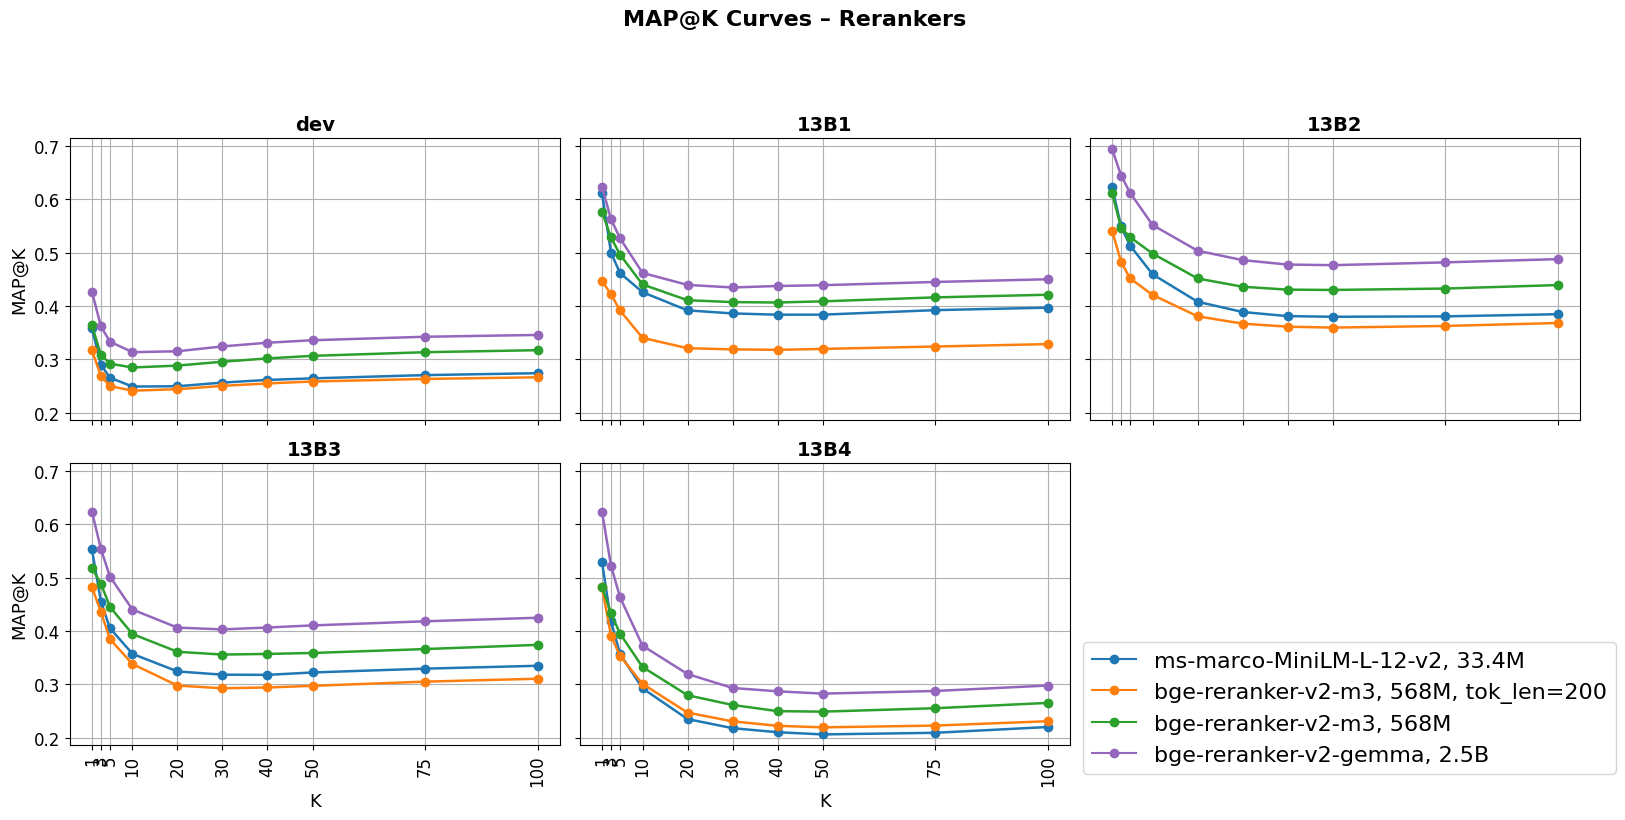

In [54]:
map_ks = [1, 3, 5, 10, 20, 30, 40, 50, 75, 100]

splits_rerank = [
    "training14b_10pct_sample",
    "13B1_golden",
    "13B2_golden",
    "13B3_golden",
    "13B4_golden",
]

rerank_only_run_dirs = {
    "ms-marco-MiniLM-L-12-v2, 33.4M": base_dir / "output" / "eval_stage2_rerank_miniLM" / "runs",
    "bge-reranker-v2-m3, 568M, tok_len=200": base_dir / "output" / "eval_stage2_rerank_bge_reranker_v2_m3_len200" / "runs",
    "bge-reranker-v2-m3, 568M": base_dir / "output" / "eval_stage2_rerank_bge_reranker_v2_m3_len512" / "runs",
    "bge-reranker-v2-gemma, 2.5B": base_dir / "output" / "workflow_baseline_full_run_both_routes_gemma" / "rerank" / "runs",
}

# Precompute overlapping qids between train and test splits based on rerank runs.
# We use the MiniLM runs as the canonical source of which train queries overlap
# with the 13B1–4 test batches, then exclude those qids from all train analyses.
train_split_id = "training14b_10pct_sample"
test_split_ids = ["13B1_golden", "13B2_golden", "13B3_golden", "13B4_golden"]
train_overlap_qids: set[str] = set()

minilm_runs_dir = rerank_only_run_dirs["ms-marco-MiniLM-L-12-v2, 33.4M"]

# Train run: best_rrf_train_subset_top*.tsv
train_candidates = list((minilm_runs_dir).glob("best_rrf_train_subset_top*.tsv"))
if train_candidates:
    train_run_df = _load_run(train_candidates[0])
    train_qid_col, _ = train_run_df.columns.tolist()
    train_qids_run = set(train_run_df[train_qid_col].astype(str).tolist())
else:
    train_qids_run = set()

test_qids_run: set[str] = set()
for s in test_split_ids:
    test_candidates = list((minilm_runs_dir).glob(f"best_rrf_{s}_top*.tsv"))
    if not test_candidates:
        continue
    test_run_df = _load_run(test_candidates[0])
    qid_col, _ = test_run_df.columns.tolist()
    test_qids_run.update(test_run_df[qid_col].astype(str).tolist())

train_overlap_qids = train_qids_run & test_qids_run

rerank_map_curves: dict[str, dict[str, dict[int, float]]] = defaultdict(dict)

for split in splits_rerank:
    qrels_split = qrels_by_split.get(split, {})
    for method_name, runs_dir in rerank_only_run_dirs.items():
        # Train/dev filenames use different stems ("train_subset" vs "training14b_10pct_sample")
        # across reranker outputs, so try both patterns for that split.
        stems = [split]
        if split == "training14b_10pct_sample":
            stems = ["train_subset", split]

        run_path = None
        for stem in stems:
            pattern = f"best_rrf_{stem}_top"
            candidates = list(runs_dir.glob(f"{pattern}*.tsv"))
            if candidates:
                run_path = candidates[0]
                break

        if run_path is None:
            continue

        run_df = _load_run(run_path)

        # For train/dev, drop any qids that overlap with test batches.
        if split == train_split_id and train_overlap_qids:
            qid_col, _ = run_df.columns.tolist()
            run_df = run_df[~run_df[qid_col].astype(str).isin(train_overlap_qids)]

        map_vals = _map_at_ks_for_run(run_df, qrels_split, map_ks)
        rerank_map_curves[method_name][split] = map_vals

fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True, sharey=True)
axes_flat = list(axes.flat)

all_vals = []
for method_dict in rerank_map_curves.values():
    for split_vals in method_dict.values():
        all_vals.extend(split_vals.values())

if all_vals:
    y_min = max(0.0, min(all_vals) - 0.02)
    y_max = min(1.0, max(all_vals) + 0.02)
else:
    y_min, y_max = 0.0, 1.0

colors_rerank = {
    "ms-marco-MiniLM-L-12-v2, 33.4M": "#1f77b4",
    "bge-reranker-v2-m3, 568M, tok_len=200": "#ff7f0e",
    "bge-reranker-v2-m3, 568M": "#2ca02c",
    "bge-reranker-v2-gemma, 2.5B": "#9467bd",
}

for idx, split in enumerate(splits_rerank):
    ax = axes_flat[idx]
    for method_name, method_dict in rerank_map_curves.items():
        if split not in method_dict:
            continue
        vals = [method_dict[split].get(k, 0.0) for k in map_ks]
        ax.plot(
            map_ks,
            vals,
            marker="o",
            linewidth=1.8,
            color=colors_rerank[method_name],
            label=method_name,
        )
    ax.set_title(split_labels.get(split, split), fontsize=14, fontweight="bold")
    ax.set_ylim(y_min, y_max)
    ax.grid(True, axis="y")
    ax.grid(True, axis="x")
    if idx % 3 == 0:
        ax.set_ylabel("MAP@K")
    if idx >= 3:
        ax.set_xlabel("K")
        ax.set_xticks(map_ks)
        ax.set_xticklabels([str(k) for k in map_ks], rotation=90)

# Hide unused last panel (6th subplot)
for j in range(len(splits_rerank), len(axes_flat)):
    axes_flat[j].set_visible(False)

from matplotlib.lines import Line2D

legend_handles = [
    Line2D([0], [0], color=colors_rerank[name], marker="o", linestyle="-", label=name)
    for name in colors_rerank.keys()
]
fig.legend(
    handles=legend_handles,
    labels=list(colors_rerank.keys()),
    loc="lower right",
    bbox_to_anchor=(1.02, 0.05),
    fontsize=16,
)
fig.suptitle("MAP@K Curves – Rerankers", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.95])
fig_path = output_dir / "07_rerankers_mapk_test_splits.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()

## 10. MedCPT – MAP@K Curves: `rerank_hybrid_200` vs `snippet_rerank`

In [ ]:
medcpt_dir = base_dir / "output" / "workflow_baseline_full_run_both_routes_MedCPT"

medcpt_run_dirs = {
    "MedCPT rerank_hybrid_200": medcpt_dir / "rerank_hybrid_200" / "runs",
    "MedCPT snippet_rerank": medcpt_dir / "snippet_rerank" / "runs",
}

medcpt_map_ks = list(range(10, 101, 10))

medcpt_map_curves: dict[str, dict[str, dict[int, float]]] = defaultdict(dict)

for split in splits_rerank:
    qrels_split = qrels_by_split.get(split, {})
    if not qrels_split:
        continue
    for method_name, runs_dir in medcpt_run_dirs.items():
        stem = f"best_rrf_{split}_top5000_rrf_poolR200_poolH200_k60"
        run_path = runs_dir / f"{stem}.tsv"
        if not run_path.exists():
            continue
        run_df = _load_run(run_path)
        # For train/dev, drop any qids that overlap with test batches (same logic as section 9).
        if split == "training14b_10pct_sample" and train_overlap_qids:
            qid_col, _ = run_df.columns.tolist()
            run_df = run_df[~run_df[qid_col].astype(str).isin(train_overlap_qids)]
        map_vals = _map_at_ks_for_run(run_df, qrels_split, medcpt_map_ks)
        medcpt_map_curves[method_name][split] = map_vals

fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True, sharey=True)
axes_flat = list(axes.flat)

all_vals_medcpt: list[float] = []
for method_dict in medcpt_map_curves.values():
    for split_vals in method_dict.values():
        all_vals_medcpt.extend(split_vals.values())

if all_vals_medcpt:
    y_min_m = max(0.0, min(all_vals_medcpt) - 0.02)
    y_max_m = min(1.0, max(all_vals_medcpt) + 0.02)
else:
    y_min_m, y_max_m = 0.0, 1.0

colors_medcpt = {
    "MedCPT rerank_hybrid_200": "#1f77b4",
    "MedCPT snippet_rerank": "#ff7f0e",
}

for idx, split in enumerate(splits_rerank):
    ax = axes_flat[idx]
    for method_name, method_dict in medcpt_map_curves.items():
        if split not in method_dict:
            continue
        vals = [method_dict[split].get(k, 0.0) for k in medcpt_map_ks]
        ax.plot(
            medcpt_map_ks,
            vals,
            marker="o",
            linewidth=1.8,
            color=colors_medcpt[method_name],
            label=method_name,
        )
    ax.set_title(split_labels.get(split, split), fontsize=14, fontweight="bold")
    ax.set_ylim(y_min_m, y_max_m)
    ax.grid(True, axis="y")
    ax.grid(True, axis="x")
    if idx % 3 == 0:
        ax.set_ylabel("MAP@K")
    if idx >= 3:
        ax.set_xlabel("K")
        ax.set_xticks(medcpt_map_ks)
        ax.set_xticklabels([str(k) for k in medcpt_map_ks], rotation=90)

for j in range(len(splits_rerank), len(axes_flat)):
    axes_flat[j].set_visible(False)

from matplotlib.lines import Line2D as _Line2D_medcpt

legend_medcpt_handles = [
    _Line2D_medcpt([0], [0], color=colors_medcpt[name], marker="o", linestyle="-", label=name)
    for name in colors_medcpt.keys()
]
fig.legend(
    handles=legend_medcpt_handles,
    labels=list(colors_medcpt.keys()),
    loc="lower right",
    bbox_to_anchor=(1.02, 0.05),
    fontsize=16,
)
fig.suptitle(
    "MedCPT – MAP@K Curves (rerank_hybrid_200 vs snippet_rerank)",
    fontsize=16,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout(rect=[0, 0, 1, 0.95])
fig_path = output_dir / "08_medcpt_rerank_hybrid200_vs_snippet_mapk.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()

## 11. MedCPT – RRF Fusion Sweep: MAP@10 vs Weight (rerank_hybrid_200 + snippet_rerank)

In [ ]:
# We reproduce the "MAP@10 vs weight config" line plots from `snippet_extraction_MedCPT.py`,
# but only for our local MedCPT snippet reranker (no external MedCPT_bge-m3 dependency),
# and using the qrels / overlap filtering already defined in this notebook.

RUN_TOP = 100
OUTPUT_TOP = 10
RRF_KS = [60]
RRF_WEIGHTS = [
    (1.0, 0.0),
    (0.9, 0.1),
    (0.8, 0.2),
    (0.7, 0.3),
    (0.6, 0.4),
    (0.5, 0.5),
    (0.4, 0.6),
    (0.3, 0.7),
    (0.2, 0.8),
    (0.1, 0.9),
    (0.0, 1.0),
]


def _build_run_map(run_df: pd.DataFrame) -> dict[str, list[str]]:
    qid_col, doc_col = run_df.columns.tolist()
    run_map: dict[str, list[str]] = {}
    for qid, group in run_df.groupby(qid_col, sort=False):
        run_map[str(qid)] = group[doc_col].astype(str).tolist()
    return run_map


def _rrf_fuse_docs(
    docs_hybrid: list[str],
    docs_snippet: list[str],
    k_rrf: int,
    w_hybrid: float,
    w_snippet: float,
    run_top: int,
    output_top: int,
) -> list[str]:
    hybrid_top = docs_hybrid[:run_top]
    snippet_top = docs_snippet[:run_top]
    rank_h = {d: i + 1 for i, d in enumerate(hybrid_top)}
    rank_s = {d: i + 1 for i, d in enumerate(snippet_top)}
    union = list(dict.fromkeys(hybrid_top + snippet_top))
    scored: list[tuple[str, float]] = []
    for d in union:
        s = 0.0
        rh = rank_h.get(d)
        rs = rank_s.get(d)
        if rh is not None:
            s += w_hybrid / (k_rrf + rh)
        if rs is not None:
            s += w_snippet / (k_rrf + rs)
        scored.append((d, s))
    scored.sort(key=lambda x: (-x[1], x[0]))
    return [d for d, _ in scored[:output_top]]


def _ap10_for_fusion(
    gold: dict[str, list[str]] | dict[str, set[str]],
    run_hybrid: dict[str, list[str]],
    run_snippet: dict[str, list[str]],
    k_rrf: int,
    w_hybrid: float,
    w_snippet: float,
) -> tuple[float, int]:
    # gold is qid -> iterable of relevant doc ids
    qids = [q for q in gold if q in run_hybrid and q in run_snippet and gold[q]]
    if not qids:
        return 0.0, 0
    ap_vals: list[float] = []
    for q in qids:
        rels = set(gold[q])
        fused_docs = _rrf_fuse_docs(
            run_hybrid[q],
            run_snippet[q],
            k_rrf=k_rrf,
            w_hybrid=w_hybrid,
            w_snippet=w_snippet,
            run_top=RUN_TOP,
            output_top=OUTPUT_TOP,
        )
        ap_vals.append(_ap_at_k(fused_docs, rels, k=OUTPUT_TOP))
    return (float(np.mean(ap_vals)) if ap_vals else 0.0, len(qids))


# Build simple gold maps from qrels_by_split (after train/dev overlap filtering).
gold_maps: dict[str, dict[str, set[str]]] = {}
for split in splits_rerank:
    qrels_split = qrels_by_split.get(split, {})
    if not qrels_split:
        continue
    if split == "training14b_10pct_sample" and train_overlap_qids:
        # Drop overlapping qids from train split golds
        gold_maps[split] = {
            qid: rels
            for qid, rels in qrels_split.items()
            if qid not in train_overlap_qids
        }
    else:
        gold_maps[split] = qrels_split

# Load MedCPT hybrid and snippet run maps.
hybrid_run_maps: dict[str, dict[str, list[str]]] = {}
snippet_run_maps: dict[str, dict[str, list[str]]] = {}

for split in splits_rerank:
    # hybrid (rerank_hybrid_200 uses poolR200_poolH200)
    stem_h = f"best_rrf_{split}_top5000_rrf_poolR200_poolH200_k60"
    path_h = (medcpt_dir / "rerank_hybrid_200" / "runs" / f"{stem_h}.tsv")
    # snippet_rerank (same stem/pool config)
    stem_s = f"best_rrf_{split}_top5000_rrf_poolR200_poolH200_k60"
    path_s = (medcpt_dir / "snippet_rerank" / "runs" / f"{stem_s}.tsv")

    if not path_h.exists() or not path_s.exists():
        continue

    df_h = _load_run(path_h)
    df_s = _load_run(path_s)

    if split == "training14b_10pct_sample" and train_overlap_qids:
        qid_col, _ = df_h.columns.tolist()
        mask = ~df_h[qid_col].astype(str).isin(train_overlap_qids)
        df_h = df_h[mask]
        mask = ~df_s[qid_col].astype(str).isin(train_overlap_qids)
        df_s = df_s[mask]

    hybrid_run_maps[split] = _build_run_map(df_h)
    snippet_run_maps[split] = _build_run_map(df_s)

# Sweep weights and compute MAP@10 per split and k_rrf
rrf_rows: list[dict[str, object]] = []

for split in splits_rerank:
    gold = gold_maps.get(split)
    run_h = hybrid_run_maps.get(split)
    run_s = snippet_run_maps.get(split)
    if not gold or not run_h or not run_s:
        continue
    for k_rrf in RRF_KS:
        for w_h, w_s in RRF_WEIGHTS:
            map10, n_q = _ap10_for_fusion(
                gold=gold,
                run_hybrid=run_h,
                run_snippet=run_s,
                k_rrf=k_rrf,
                w_hybrid=w_h,
                w_snippet=w_s,
            )
            rrf_rows.append(
                {
                    "split": split,
                    "k_rrf": k_rrf,
                    "w_hybrid": w_h,
                    "w_snippet": w_s,
                    "MAP@10": map10,
                    "n_queries": n_q,
                }
            )

rrf_results = pd.DataFrame(rrf_rows)
if not rrf_results.empty:
    rrf_results["weight_label"] = rrf_results.apply(
        lambda r: f"({r['w_hybrid']:.1f},{r['w_snippet']:.1f})",
        axis=1,
    )

weight_order = [f"({w[0]:.1f},{w[1]:.1f})" for w in RRF_WEIGHTS]

# Line plot: MAP@10 vs weight config — one line per (k_rrf, snippet_label=MedCPT), one panel per split
if not rrf_results.empty:
    n_splits = rrf_results["split"].nunique()
    n_cols = min(3, n_splits)
    n_rows = (n_splits + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), sharey=True)
    if n_splits == 1:
        axes = np.array([axes])
    axes_flat = axes.flat

    for ax, (split, grp) in zip(axes_flat, rrf_results.groupby("split", sort=False)):
        for k_rrf in sorted(grp["k_rrf"].unique()):
            sub = grp[grp["k_rrf"] == k_rrf].set_index("weight_label").reindex(weight_order)
            vals = sub["MAP@10"].values
            ax.plot(
                range(len(weight_order)),
                vals,
                marker="o",
                linewidth=1.6,
                label=f"k_rrf={k_rrf}, MedCPT",
            )
        ax.set_xticks(range(len(weight_order)))
        ax.set_xticklabels(weight_order, rotation=45, ha="right")
        n_q = int(grp["n_queries"].max())
        ax.set_title(f"{split_labels.get(split, split)} (n={n_q})", fontsize=12, fontweight="bold")
        ax.set_ylabel("MAP@10")
        ax.set_xlabel("(w_hybrid, w_snippet)")
        ax.grid(True, axis="y")
    # Hide any unused axes
    for ax in list(axes_flat)[n_splits:]:
        ax.set_visible(False)

    handles, labels = axes_flat[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=len(labels), bbox_to_anchor=(0.5, 1.05), fontsize=12)
    fig.suptitle("MedCPT – MAP@10 vs RRF Weight (rerank_hybrid_200 + snippet_rerank)", fontsize=16, fontweight="bold", y=1.08)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    fig_path = output_dir / "09_medcpt_rrf_fusion_map10_vs_weight.png"
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    print("Saved:", fig_path)
    plt.show()